In [2]:
import sys
!{sys.executable} -m pip install fairlearn -q

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio
)
from fairlearn.postprocessing import ThresholdOptimizer

RANDOM_STATE = 42

In [4]:
# for graphs
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

### Loading the dataset and basic preprocessing

In [5]:
# Attempt to use a local relative path, fallback to error if file not found
import os

possible_paths = [
    "data/raw/dst-3.0_16_1_hh_database.csv",      # relative to project root
    "./data/raw/dst-3.0_16_1_hh_database.csv",    # relative to CWD
    "../data/raw/dst-3.0_16_1_hh_database.csv",   # relative to possible 'notebooks' subdir
    "/data/raw/dst-3.0_16_1_hh_database.csv",     # absolute (original)
]

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break
else:
    raise FileNotFoundError(
        "Data file dst-3.0_16_1_hh_database.csv not found in any of the expected locations: " +
        ", ".join(possible_paths)
    )
hh = pd.read_csv(data_path, sep=";")

print(hh.shape)
hh.head()

(44744, 12)


,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


### IT or Non-IT

In [6]:
# looking for the needed column
print(hh.columns.tolist())

['Пол, возраст', 'ЗП', 'Ищет работу на должность:', 'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Образование и ВУЗ', 'Обновление резюме', 'Авто']


In [7]:
TARGET_SOURCE_COL = "Ищет работу на должность:"
assert TARGET_SOURCE_COL in hh.columns, f"Колонки {TARGET_SOURCE_COL} нет в датасете"

In [8]:
def is_it_position(title: str) -> int:
    """
    Returns 1 if the position belongs to IT (based on a set of heuristic substrings), otherwise 0.
    """
    if pd.isna(title):
        return 0
    t = str(title).lower()

    it_keywords = [
        "программист", "разработчик", "developer", "software engineer",
        "frontend", "front-end", "back-end", "backend", "fullstack", "full-stack",
        "qa", "тестировщик", "test engineer", "automation", "sdet",
        "data scientist", "data science", "ds ", "ml engineer", "machine learning",
        "devops", "site reliability", "sre",
        "sysadmin", "системный администратор",
        "администратор баз данных", "dba",
        "аналитик данных", "data analyst", "bi analyst",
        "product analyst", "system analyst", "business analyst",
        "android разработчик", "ios разработчик", "mobile developer",
        "unity", "unreal", "game developer", "игровой разработчик"
    ]

    for kw in it_keywords:
        if kw in t:
            return 1
    return 0

hh["is_it"] = hh[TARGET_SOURCE_COL].apply(is_it_position)
hh["is_it"].value_counts(normalize=True)

is_it
0    0.710665
1    0.289335
Name: proportion, dtype: float64

### Sensitive attribute

In [9]:
MILLION_CITIES = [
    "Новосибирск", "Екатеринбург", "Нижний Новгород",
    "Казань", "Челябинск", "Омск", "Самара", "Ростов-на-Дону",
    "Уфа", "Красноярск", "Пермь", "Воронеж", "Волгоград"
]

def get_city_group(raw: str):
    """
    Takes a string from the 'Город, переезд, командировки' column and returns one of the categories:
    'Москва', 'Санкт-Петербург', 'город-миллионник', 'другие'.
    """
    if pd.isna(raw):
        return np.nan
    s = str(raw)

    city = s.split(",")[0].strip()

    if city.lower().startswith("г."):
        city = city[2:].strip()

    if city == "Москва":
        return "Москва"
    if city == "Санкт-Петербург":
        return "Санкт-Петербург"
    if city in MILLION_CITIES:
        return "город-миллионник"
    return "другие"

CITY_COL_RAW = "Город, переезд, командировки"
assert CITY_COL_RAW in hh.columns, f"Колонки {CITY_COL_RAW} нет в датасете"

hh["city_group"] = hh[CITY_COL_RAW].apply(get_city_group)
hh["city_group"].value_counts(dropna=False)


city_group
Москва              16621
другие              15854
город-миллионник     7332
Санкт-Петербург      4937
Name: count, dtype: int64

### Forming the text field for the model
We want the model to see work experience, education, the last position, and the city. We'll use the columns we've already encountered in the previous notebook:

- "Опыт работы" (Work Experience)
- "Последняя/нынешняя должность" (Last/Current Position)
- "Последнее/нынешнее место работы" (Last/Current Workplace)
- "Образование и ВУЗ" (Education and University)
- the raw city string "Город, переезд, командировки" (City, Relocation, Business Trips)

In [10]:
TEXT_COLS = [
    "Опыт работы",
    "Последняя/нынешняя должность",
    "Последнее/нынешнее место работы",
    "Образование и ВУЗ",
    "Город, переезд, командировки",
]

for col in TEXT_COLS:
    if col not in hh.columns:
        print(f"ВНИМАНИЕ: колонки {col} нет в датасете.")

In [11]:
# combining the text columns
def build_text(row) -> str:
    parts = []
    for col in TEXT_COLS:
        if col in row and pd.notna(row[col]):
            parts.append(str(row[col]))
    return " ".join(parts)

hh["text"] = hh.apply(build_text, axis=1)
hh[["text", "is_it", "city_group"]].head()

,text,is_it,city_group
0,Опыт работы 16 лет 10 месяцев Август 2010 — п...,1,другие
1,Опыт работы 19 лет 5 месяцев Январь 2000 — по...,0,другие
2,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,0,другие
3,Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,1,другие
4,Опыт работы 5 лет 7 месяцев Региональный мене...,0,Москва


The final dataset for the first iteration. We need a DataFrame with:
- text — input;
- y — binary label IT / non-IT;
- city_group — sensitive attribute.
And let's clean missing values a bit (drop rows where the label or city are missing):

In [12]:
df = hh[["text", "is_it", "city_group"]].copy()
df = df.dropna(subset=["text", "is_it", "city_group"])

df["y"] = df["is_it"].astype(int)
df = df.drop(columns=["is_it"])

df.head(), df["y"].value_counts(normalize=True), df["city_group"].value_counts(normalize=True)

(                                                text city_group  y
 0  Опыт работы 16 лет 10 месяцев  Август 2010 — п...     другие  1
 1  Опыт работы 19 лет 5 месяцев  Январь 2000 — по...     другие  0
 2  Опыт работы 10 лет 3 месяца  Октябрь 2004 — Де...     другие  0
 3  Опыт работы 18 лет 9 месяцев  Август 2017 — Ап...     другие  1
 4  Опыт работы 5 лет 7 месяцев  Региональный мене...     Москва  0,
 y
 0    0.710665
 1    0.289335
 Name: proportion, dtype: float64,
 city_group
 Москва              0.371469
 другие              0.354327
 город-миллионник    0.163866
 Санкт-Петербург     0.110339
 Name: proportion, dtype: float64)

## train / val / test split

In [13]:
X = df["text"].values
y = df["y"].values
A = df["city_group"].values   # sensitive attribute

X_train_val, X_test, y_train_val, y_test, A_train_val, A_test = train_test_split(
    X, y, A,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val, A_train, A_val = train_test_split(
    X_train_val, y_train_val, A_train_val,
    test_size=0.25,   # 0.25 of 0.8 = 0.2
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

len(X_train), len(X_val), len(X_test)

(26846, 8949, 8949)

### Baseline TF-IDF + Logistic Regression

In [14]:
baseline_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=5
    )),
    ("logreg", LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

baseline_clf.fit(X_train, y_train)

y_val_proba = baseline_clf.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= 0.5).astype(int)

print("Baseline on validation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba))

Baseline on validation:
Accuracy: 0.8636719186501285
F1: 0.7392047883710987
ROC-AUC: 0.9247588369759819


### Utility & fairness metrics

In [15]:
# utility metrics
def compute_utility(y_true, y_pred, y_score):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_score)
    except ValueError:
        metrics["roc_auc"] = np.nan
    return metrics

In [16]:
# fairness metrics
def compute_fairness(y_true, y_pred, sensitive):
    # numpy arrays for compatibility
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    sensitive = np.asarray(sensitive)

    # length check
    assert len(y_true) == len(y_pred) == len(sensitive), (
        f"Lengths mismatch: y_true={len(y_true)}, y_pred={len(y_pred)}, sensitive={len(sensitive)}"
    )

    mf = MetricFrame(
        metrics={
            "selection_rate": lambda yt, yp: np.mean(yp),
            "accuracy": accuracy_score,
            "f1": f1_score,
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    dp_diff = demographic_parity_difference(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )
    dp_ratio = demographic_parity_ratio(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    eo_diff = equalized_odds_difference(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )
    eo_ratio = equalized_odds_ratio(
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    return {
        "by_group": mf.by_group.to_dict(),
        "overall": mf.overall.to_dict(),
        "dp_difference": dp_diff,
        "dp_ratio": dp_ratio,
        "eo_difference": eo_diff,
        "eo_ratio": eo_ratio,
    }

In [17]:
# baseline utility & fairness metrics
y_test_proba = baseline_clf.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

baseline_utility = compute_utility(y_test, y_test_pred, y_test_proba)
baseline_fairness = compute_fairness(y_test, y_test_pred, A_test)

print("Baseline utility:")
print(baseline_utility)
print("\nBaseline fairness:")
print(baseline_fairness)

Baseline utility:
{'accuracy': 0.8640071516370544, 'f1': 0.7424338624338624, 'roc_auc': np.float64(0.9254017966675654)}

Baseline fairness:
{'by_group': {'selection_rate': {'Москва': 0.22354694485842028, 'Санкт-Петербург': 0.2245508982035928, 'город-миллионник': 0.21537396121883656, 'другие': 0.27001270648030495}, 'accuracy': {'Москва': 0.8831594634873323, 'Санкт-Петербург': 0.8502994011976048, 'город-миллионник': 0.8601108033240997, 'другие': 0.8497458703939009}, 'f1': {'Москва': 0.7546933667083855, 'Санкт-Петербург': 0.708171206225681, 'город-миллионник': 0.7202216066481995, 'другие': 0.7498677948175568}}, 'overall': {'selection_rate': 0.23868588669125043, 'accuracy': 0.8640071516370544, 'f1': 0.7424338624338624}, 'dp_difference': np.float64(0.05463874526146839), 'dp_ratio': np.float64(0.7976437999022323), 'eo_difference': 0.08132712019324939, 'eo_ratio': 0.7377602932998291}


In [18]:
# a quick check
print("len(y_test)      =", len(y_test))
print("len(y_test_pred) =", len(y_test_pred))
print("len(A_test)      =", len(A_test))

len(y_test)      = 8949
len(y_test_pred) = 8949
len(A_test)      = 8949


### Simple custom post-processing: group thresholds for Demographic Parity
Let's say we have validation data: y_val_proba, A_val.

- we'll compute the target selection rate (fraction of predicted positives) - take the one given by the baseline at threshold 0.5;
- for each group by city_group, we'll choose its own threshold so that its selection rate is as close as possible to the target;
- then on the test set, we'll use each group's own threshold.

In [19]:
import numpy as np
import pandas as pd

def fit_group_thresholds_for_dp(scores, sensitive, target_selection_rate, grid_size=100):
    """
    Chooses thresholds for groups to approximate Demographic Parity:
    for each group, we select a threshold such that the selection_rate of the group
    is as close as possible to target_selection_rate.

    scores: 1D numpy array, probabilities of class 1 (e.g. y_val_proba)
    sensitive: 1D array with group names (A_val)
    target_selection_rate: float, target selection_rate (e.g. overall in the sample)
    grid_size: how many thresholds to try
    """
    scores = np.asarray(scores)
    sensitive = np.asarray(sensitive)

    thresholds = {}

    for group in np.unique(sensitive):
        mask = (sensitive == group)
        group_scores = scores[mask]

        if len(group_scores) == 0:
            continue

        # generate a list of candidate thresholds by quantiles
        quantiles = np.linspace(0.0, 1.0, grid_size)
        candidate_thresholds = np.quantile(group_scores, quantiles)

        best_t = 0.5
        best_diff = 1.0

        for t in candidate_thresholds:
            sel_rate = np.mean(group_scores >= t)
            diff = abs(sel_rate - target_selection_rate)
            if diff < best_diff:
                best_diff = diff
                best_t = t

        thresholds[group] = best_t

    return thresholds


def apply_group_thresholds(scores, sensitive, thresholds, default_threshold=0.5):
    """
    Applies group thresholds:
    scores: 1D array of probabilities
    sensitive: 1D array of group names
    thresholds: dict: group -> threshold
    default_threshold: what to do if the group is not in thresholds
    """
    scores = np.asarray(scores)
    sensitive = np.asarray(sensitive)

    preds = np.zeros_like(scores, dtype=int)
    for i, (s, g) in enumerate(zip(scores, sensitive)):
        t = thresholds.get(g, default_threshold)
        preds[i] = int(s >= t)
    return preds


In [20]:
# 1) baseline is already trained, we have y_val_proba and y_test_proba

# baseline threshold 0.5
y_val_pred_base = (y_val_proba >= 0.5).astype(int)
base_selection_rate = np.mean(y_val_pred_base)

print("Baseline validation selection_rate:", base_selection_rate)

# 2) we fit thresholds for groups on the validation set
group_thresholds = fit_group_thresholds_for_dp(
    scores=y_val_proba,
    sensitive=A_val,
    target_selection_rate=base_selection_rate,
    grid_size=100
)

print("Групповые пороги для city_group:")
for g, t in group_thresholds.items():
    print(f"  {g}: {t:.4f}")

# 3) apply them on the test set
y_test_pred_fair = apply_group_thresholds(
    scores=y_test_proba,
    sensitive=A_test,
    thresholds=group_thresholds,
    default_threshold=0.5
)

# 4) compute metrics for the fair version
y_test_proba_fair = y_test_proba  # the scoring for ROC-AUC is the same

fair_utility = compute_utility(y_test, y_test_pred_fair, y_test_proba_fair)
fair_fairness = compute_fairness(y_test, y_test_pred_fair, A_test)

print("Fair model utility:")
print(fair_utility)
print("\nFair model fairness:")
print(fair_fairness)


Baseline validation selection_rate: 0.2334339032294111
Групповые пороги для city_group:
  Москва: 0.4744
  Санкт-Петербург: 0.4410
  город-миллионник: 0.4821
  другие: 0.5474
Fair model utility:
{'accuracy': 0.8630014526762767, 'f1': 0.7395921835174172, 'roc_auc': np.float64(0.9254017966675654)}

Fair model fairness:
{'by_group': {'selection_rate': {'Москва': 0.2330849478390462, 'Санкт-Петербург': 0.2405189620758483, 'город-миллионник': 0.2188365650969529, 'другие': 0.24777636594663277}, 'accuracy': {'Москва': 0.8837555886736215, 'Санкт-Петербург': 0.8562874251497006, 'город-миллионник': 0.8635734072022161, 'другие': 0.8427573062261754}, 'f1': {'Москва': 0.7607361963190185, 'Санкт-Петербург': 0.7283018867924528, 'город-миллионник': 0.7290233837689133, 'другие': 0.728171334431631}}, 'overall': {'selection_rate': 0.23678623309867025, 'accuracy': 0.8630014526762767, 'f1': 0.7395921835174172}, 'dp_difference': np.float64(0.02893980084967987), 'dp_ratio': np.float64(0.8832019319553945), 'eo

#### Let's compare baseline vs fair version

In [21]:
def compare_models(b_util, b_fair, f_util, f_fair):
    print("=== Utility ===")
    print("Baseline:", b_util)
    print("Fair    :", f_util)
    print()
    print("=== Fairness (DP / EO) ===")
    print("Baseline DP diff:", b_fair["dp_difference"])
    print("Fair     DP diff:", f_fair["dp_difference"])
    print("Baseline EO diff:", b_fair["eo_difference"])
    print("Fair     EO diff:", f_fair["eo_difference"])

compare_models(baseline_utility, baseline_fairness, fair_utility, fair_fairness)


=== Utility ===
Baseline: {'accuracy': 0.8640071516370544, 'f1': 0.7424338624338624, 'roc_auc': np.float64(0.9254017966675654)}
Fair    : {'accuracy': 0.8630014526762767, 'f1': 0.7395921835174172, 'roc_auc': np.float64(0.9254017966675654)}

=== Fairness (DP / EO) ===
Baseline DP diff: 0.05463874526146839
Fair     DP diff: 0.02893980084967987
Baseline EO diff: 0.08132712019324939
Fair     EO diff: 0.0942444674025339


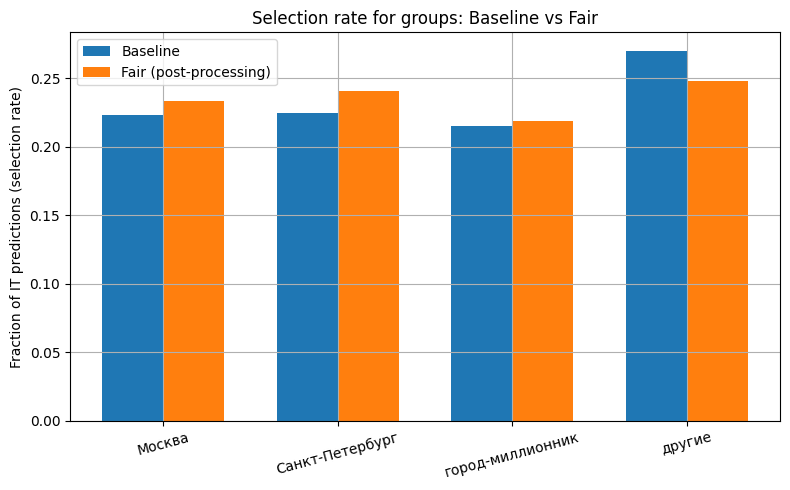

In [22]:
# Graph 1. Selection rate for groups: Baseline vs Fair

# Groups in a fixed order
groups = list(baseline_fairness["by_group"]["selection_rate"].keys())

baseline_sel = [baseline_fairness["by_group"]["selection_rate"][g] for g in groups]
fair_sel = [fair_fairness["by_group"]["selection_rate"][g] for g in groups]

x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, baseline_sel, width, label="Baseline")
ax.bar(x + width/2, fair_sel, width, label="Fair (post-processing)")

ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel("Fraction of IT predictions (selection rate)")
ax.set_title("Selection rate for groups: Baseline vs Fair")
ax.legend()

plt.tight_layout()
plt.show()


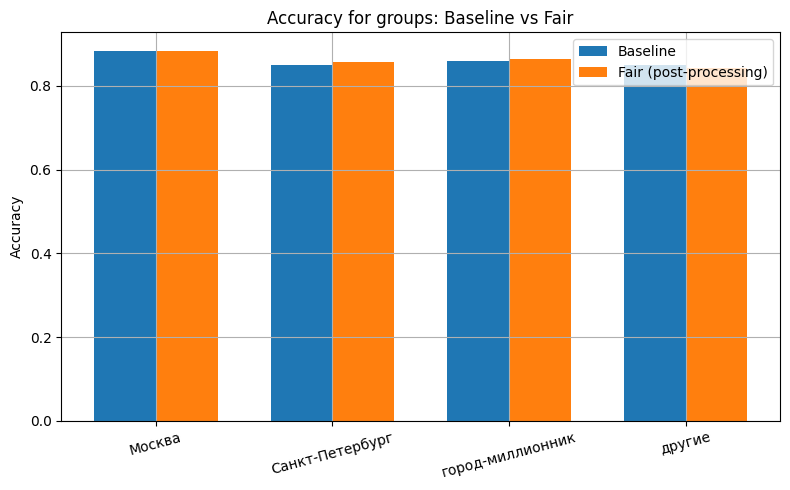

In [23]:
# Graph 2. Accuracy for groups: Baseline vs Fair

groups = list(baseline_fairness["by_group"]["accuracy"].keys())

baseline_acc = [baseline_fairness["by_group"]["accuracy"][g] for g in groups]
fair_acc = [fair_fairness["by_group"]["accuracy"][g] for g in groups]

x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, baseline_acc, width, label="Baseline")
ax.bar(x + width/2, fair_acc, width, label="Fair (post-processing)")

ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy for groups: Baseline vs Fair")
ax.legend()

plt.tight_layout()
plt.show()


#### Counterfactual score-shift by city
Idea: we take a subset of resumes where city_group == "Moscow", create a counterfactual — change the city to, for example, "Kazan" (a million-plus city), reconstruct the text and see how the score changes. We'll need the original hh again, because it has a separate city column. Let's make a careful function for this.

In [24]:
# we'll only take resumes where the city is defined and belongs to Moscow
cf_base = hh.dropna(subset=[CITY_COL_RAW]).copy()
cf_base = cf_base[cf_base["city_group"] == "Москва"].copy()

print("Всего резюме из Москвы для CF:", len(cf_base))

cf_base = cf_base.sample(n=min(500, len(cf_base)), random_state=RANDOM_STATE)

orig_texts = []
cf_texts = []
orig_groups = []
cf_groups = []

def make_cf_city(row, new_city: str) -> str:
    """Заменяет в строке 'Город, переезд, командировки' город на new_city."""
    raw = row[CITY_COL_RAW]
    if pd.isna(raw):
        return new_city
    parts = str(raw).split(",")
    parts[0] = new_city
    return ",".join(p.strip() for p in parts)

for _, row in cf_base.iterrows():
    row_orig = row.copy()
    row_cf = row.copy()

    # Original: Moscow
    city_orig_str = row_orig[CITY_COL_RAW]
    group_orig = get_city_group(city_orig_str)

    # Counterfactual: same person, but city changed to Kazan
    row_cf[CITY_COL_RAW] = make_cf_city(row, "Kazan")
    city_cf_str = row_cf[CITY_COL_RAW]
    group_cf = get_city_group(city_cf_str)

    # reuse existing text-building logic from the main dataset
    text_orig = build_text(row_orig)
    text_cf = build_text(row_cf)

    orig_texts.append(text_orig)
    cf_texts.append(text_cf)
    orig_groups.append(group_orig)
    cf_groups.append(group_cf)

df_cf = pd.DataFrame({
    "text_orig": orig_texts,
    "text_cf": cf_texts,
    "group_orig": orig_groups,
    "group_cf": cf_groups,
})

df_cf.head()


Всего резюме из Москвы для CF: 16621


,text_orig,text_cf,group_orig,group_cf
0,Опыт работы 21 год 6 месяцев Октябрь 2016 — п...,Опыт работы 21 год 6 месяцев Октябрь 2016 — п...,Москва,другие
1,Опыт работы 18 лет 10 месяцев Руководитель от...,Опыт работы 18 лет 10 месяцев Руководитель от...,Москва,другие
2,Опыт работы 3 года 4 месяца Октябрь 2017 — по...,Опыт работы 3 года 4 месяца Октябрь 2017 — по...,Москва,другие
3,Опыт работы 17 лет 11 месяцев Апрель 2017 — Я...,Опыт работы 17 лет 11 месяцев Апрель 2017 — Я...,Москва,другие
4,Опыт работы 3 года 10 месяцев Апрель 2018 — М...,Опыт работы 3 года 10 месяцев Апрель 2018 — М...,Москва,другие


In [25]:
def compute_cf_score_shift_baseline(model, df_cf):
    """
    Computes the average absolute difference in scoring when changing the city:
    E |s(x) - s(x_cf)|
    """
    s_orig = model.predict_proba(df_cf["text_orig"])[:, 1]
    s_cf = model.predict_proba(df_cf["text_cf"])[:, 1]
    shift_mean = float(np.mean(np.abs(s_orig - s_cf)))
    return {
        "mean_abs_score_shift": shift_mean,
        "score_orig_mean": float(np.mean(s_orig)),
        "score_cf_mean": float(np.mean(s_cf)),
    }

cf_score_baseline = compute_cf_score_shift_baseline(baseline_clf, df_cf)
print("Baseline CF score shift:", cf_score_baseline)

Baseline CF score shift: {'mean_abs_score_shift': 0.0014066476054131081, 'score_orig_mean': 0.26878753196917976, 'score_cf_mean': 0.2699491184470244}


In [26]:
def compute_cf_flip_rate_baseline(model, df_cf):
    y_orig = model.predict(df_cf["text_orig"])
    y_cf = model.predict(df_cf["text_cf"])
    flip_rate = float(np.mean(y_orig != y_cf))
    return {"flip_rate": flip_rate}

cf_flip_baseline = compute_cf_flip_rate_baseline(baseline_clf, df_cf)
print("Baseline CF flip rate:", cf_flip_baseline)

Baseline CF flip rate: {'flip_rate': 0.0}


In [27]:
def compute_cf_flip_rate_fair(model, df_cf, thresholds, default_threshold=0.5):
    """
    model: baseline_clf (даёт predict_proba)
    thresholds: словарь group -> threshold (наш group_thresholds)
    """
    # скор для оригинала и контрфакта
    s_orig = model.predict_proba(df_cf["text_orig"])[:, 1]
    s_cf = model.predict_proba(df_cf["text_cf"])[:, 1]

    # группы
    groups_orig = df_cf["group_orig"].values
    groups_cf = df_cf["group_cf"].values

    # бинарные предсказания с групповыми порогами
    y_orig = apply_group_thresholds(s_orig, groups_orig, thresholds, default_threshold)
    y_cf = apply_group_thresholds(s_cf, groups_cf, thresholds, default_threshold)

    flip_rate = float(np.mean(y_orig != y_cf))
    return {"flip_rate": flip_rate}

cf_flip_fair = compute_cf_flip_rate_fair(
    baseline_clf,
    df_cf,
    group_thresholds,
    default_threshold=0.5
)

print("Fair CF flip rate:", cf_flip_fair)

Fair CF flip rate: {'flip_rate': 0.032}


In [28]:
try:
    cf_score_fair
except NameError:
    cf_score_fair = cf_score_baseline

In [29]:
report = {
    "settings": {
        "model": "TFIDF + LogisticRegression",
        "sensitive_attribute": "city_group",
        "fairness_method": "group-specific thresholds for Demographic Parity (post-processing)",
        "target_task": "Binary classification: IT vs non-IT (по желаемой должности)"
    },
    "baseline": {
        "utility": baseline_utility,
        "fairness": baseline_fairness,
        "cf_score_shift": cf_score_baseline,
        "cf_flip": cf_flip_baseline,
    },
    "fair_model": {
        "utility": fair_utility,
        "fairness": fair_fairness,
        "cf_score_shift": cf_score_fair,
        "cf_flip": cf_flip_fair,
        "group_thresholds": group_thresholds,
    }
}

import pprint
pprint.pprint(report, width=120)

{'baseline': {'cf_flip': {'flip_rate': 0.0},
              'cf_score_shift': {'mean_abs_score_shift': 0.0014066476054131081,
                                 'score_cf_mean': 0.2699491184470244,
                                 'score_orig_mean': 0.26878753196917976},
              'fairness': {'by_group': {'accuracy': {'Москва': 0.8831594634873323,
                                                     'Санкт-Петербург': 0.8502994011976048,
                                                     'город-миллионник': 0.8601108033240997,
                                                     'другие': 0.8497458703939009},
                                        'f1': {'Москва': 0.7546933667083855,
                                               'Санкт-Петербург': 0.708171206225681,
                                               'город-миллионник': 0.7202216066481995,
                                               'другие': 0.7498677948175568},
                                        'selection_r

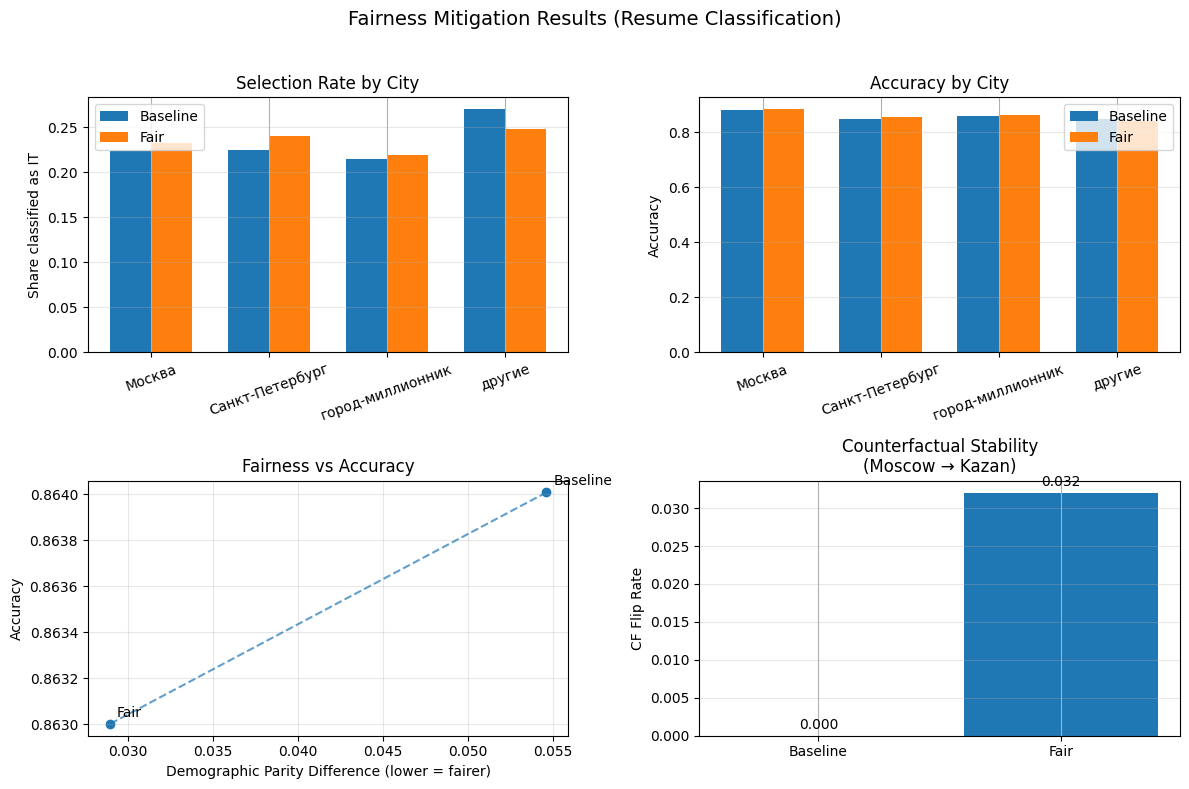

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

groups = list(baseline_fairness["by_group"]["selection_rate"].keys())

baseline_sel = [baseline_fairness["by_group"]["selection_rate"][g] for g in groups]
fair_sel     = [fair_fairness["by_group"]["selection_rate"][g]     for g in groups]

baseline_acc = [baseline_fairness["by_group"]["accuracy"][g] for g in groups]
fair_acc     = [fair_fairness["by_group"]["accuracy"][g]     for g in groups]

x_dp = [baseline_fairness["dp_difference"], fair_fairness["dp_difference"]]
y_acc = [baseline_utility["accuracy"],      fair_utility["accuracy"]]
labels = ["Baseline", "Fair"]

flip_rates = [cf_flip_baseline["flip_rate"], cf_flip_fair["flip_rate"]]
models_cf = ["Baseline", "Fair"]

# --- 1) Selection Rate ---
ax = axs[0, 0]
x = np.arange(len(groups))
width = 0.35
ax.bar(x - width/2, baseline_sel, width, label="Baseline")
ax.bar(x + width/2, fair_sel,     width, label="Fair")
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=20)
ax.set_ylabel("Share classified as IT")
ax.set_title("Selection Rate by City")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# --- 2) Accuracy by City ---
ax = axs[0, 1]
ax.bar(x - width/2, baseline_acc, width, label="Baseline")
ax.bar(x + width/2, fair_acc,     width, label="Fair")
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=20)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by City")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

# --- 3) Trade-off ---
ax = axs[1, 0]
ax.scatter(x_dp, y_acc)
for x_val, y_val, lab in zip(x_dp, y_acc, labels):
    ax.annotate(lab, (x_val, y_val), textcoords="offset points", xytext=(5, 5))

ax.plot(x_dp, y_acc, linestyle="--", alpha=0.7)
ax.set_xlabel("Demographic Parity Difference (lower = fairer)")
ax.set_ylabel("Accuracy")
ax.set_title("Fairness vs Accuracy")
ax.grid(True, alpha=0.3)

# --- 4) Counterfactual Flip Rate ---
ax = axs[1, 1]
bars = ax.bar(models_cf, flip_rates)
ax.set_ylabel("CF Flip Rate")
ax.set_title("Counterfactual Stability\n(Moscow → Kazan)")
for bar in bars:
    height = bar.get_height()
    ax.annotate(f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom")
ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Fairness Mitigation Results (Resume Classification)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# ensure figures folder exists and save the image there
os.makedirs("figures", exist_ok=True)
plt.savefig("../figures/fairness_summary_clean.png", dpi=300)
plt.show()


In [31]:
# SAVE ARTIFACTS: TFIDF baseline + thresholds/report

from pathlib import Path
import json
import joblib

REPO_ROOT = Path.cwd()
ART_DIR = REPO_ROOT / "models" / "tfidf_logreg_binary_it"
ART_DIR.mkdir(parents=True, exist_ok=True)

# baseline pipeline
joblib.dump(baseline_clf, ART_DIR / "baseline_clf.joblib")

# thresholds / report
with open(ART_DIR / "group_thresholds.json", "w", encoding="utf-8") as f:
    json.dump(group_thresholds, f, ensure_ascii=False, indent=2)

with open(ART_DIR / "report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("DONE. Saved to:", ART_DIR)

DONE. Saved to: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/models/tfidf_logreg_binary_it


In [33]:
# smoke test

import joblib
from pathlib import Path
import numpy as np

REPO_ROOT = Path.cwd()
ART_DIR = REPO_ROOT / "models" / "tfidf_logreg_binary_it"

clf = joblib.load(ART_DIR / "baseline_clf.joblib")

x = ["python developer pytorch transformers", "sales manager b2b cold calls"]
pred = clf.predict(x)
proba = clf.predict_proba(x)

print("pred:", pred)
print("proba shape:", proba.shape)
print("proba[0] sum:", float(np.sum(proba[0])))

pred: [1 0]
proba shape: (2, 2)
proba[0] sum: 1.0
